In [ ]:
!pip install -q datasets pillow torch torchvision transformers pix2tex
print("All packages installed")

All packages installed


## Libraries

In [ ]:
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader, random_split
import torch
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import re

print("imported successfully")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


imported successfully
PyTorch version: 2.9.0+cu126
CUDA available: True


## Dataset Loading

In [ ]:
print("Loading LaTeX OCR Dataset")

dataset = load_dataset("linxy/LaTeX_OCR", split="train")
print(f"   Total samples: {len(dataset):,}")
print(f"   Columns: {dataset.column_names}")

# Map column names
if 'formula' in dataset.column_names:
    dataset = dataset.rename_column('formula', 'text')
elif 'caption' in dataset.column_names:
    dataset = dataset.rename_column('caption', 'text')

print(f"\nSample formulas:")
for i in range(5):
    formula = dataset[i]['text']
    print(f"   {i+1}. {formula[:60]}{'...' if len(formula) > 60 else ''}")


Loading LaTeX OCR Dataset


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


   Total samples: 76,318
   Columns: ['image', 'text']

Sample formulas:
   1. d s ^ { 2 } = ( 1 - { \frac { q c o s \theta } { r } } ) ^ {...
   2. \widetilde \gamma _ { \mathrm { h o p f } } \simeq \sum _ { ...
   3. \rho _ { L } ( q ) = \sum _ { m = 1 } ^ { L } \ P _ { L } ( ...
   4. { \frac { d ^ { 2 } \varphi } { d \tau ^ { 2 } } } = \sin \v...
   5. | t _ { i , j } | ^ { 2 } \leq t _ { i , i } t _ { j , j } ,...


## Data Preprocessing

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transformations done")


Transformations done


In [ ]:
class LaTeXOCRDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.data = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        # Get image
        image = item['image']
        if not isinstance(image, Image.Image):
            image = Image.open(image).convert('RGB')
        else:
            image = image.convert('RGB')

        latex = item['text']

        if self.transform:
            image = self.transform(image)

        return image, latex

print("Dataset class created")

Dataset class created


## Data Preview

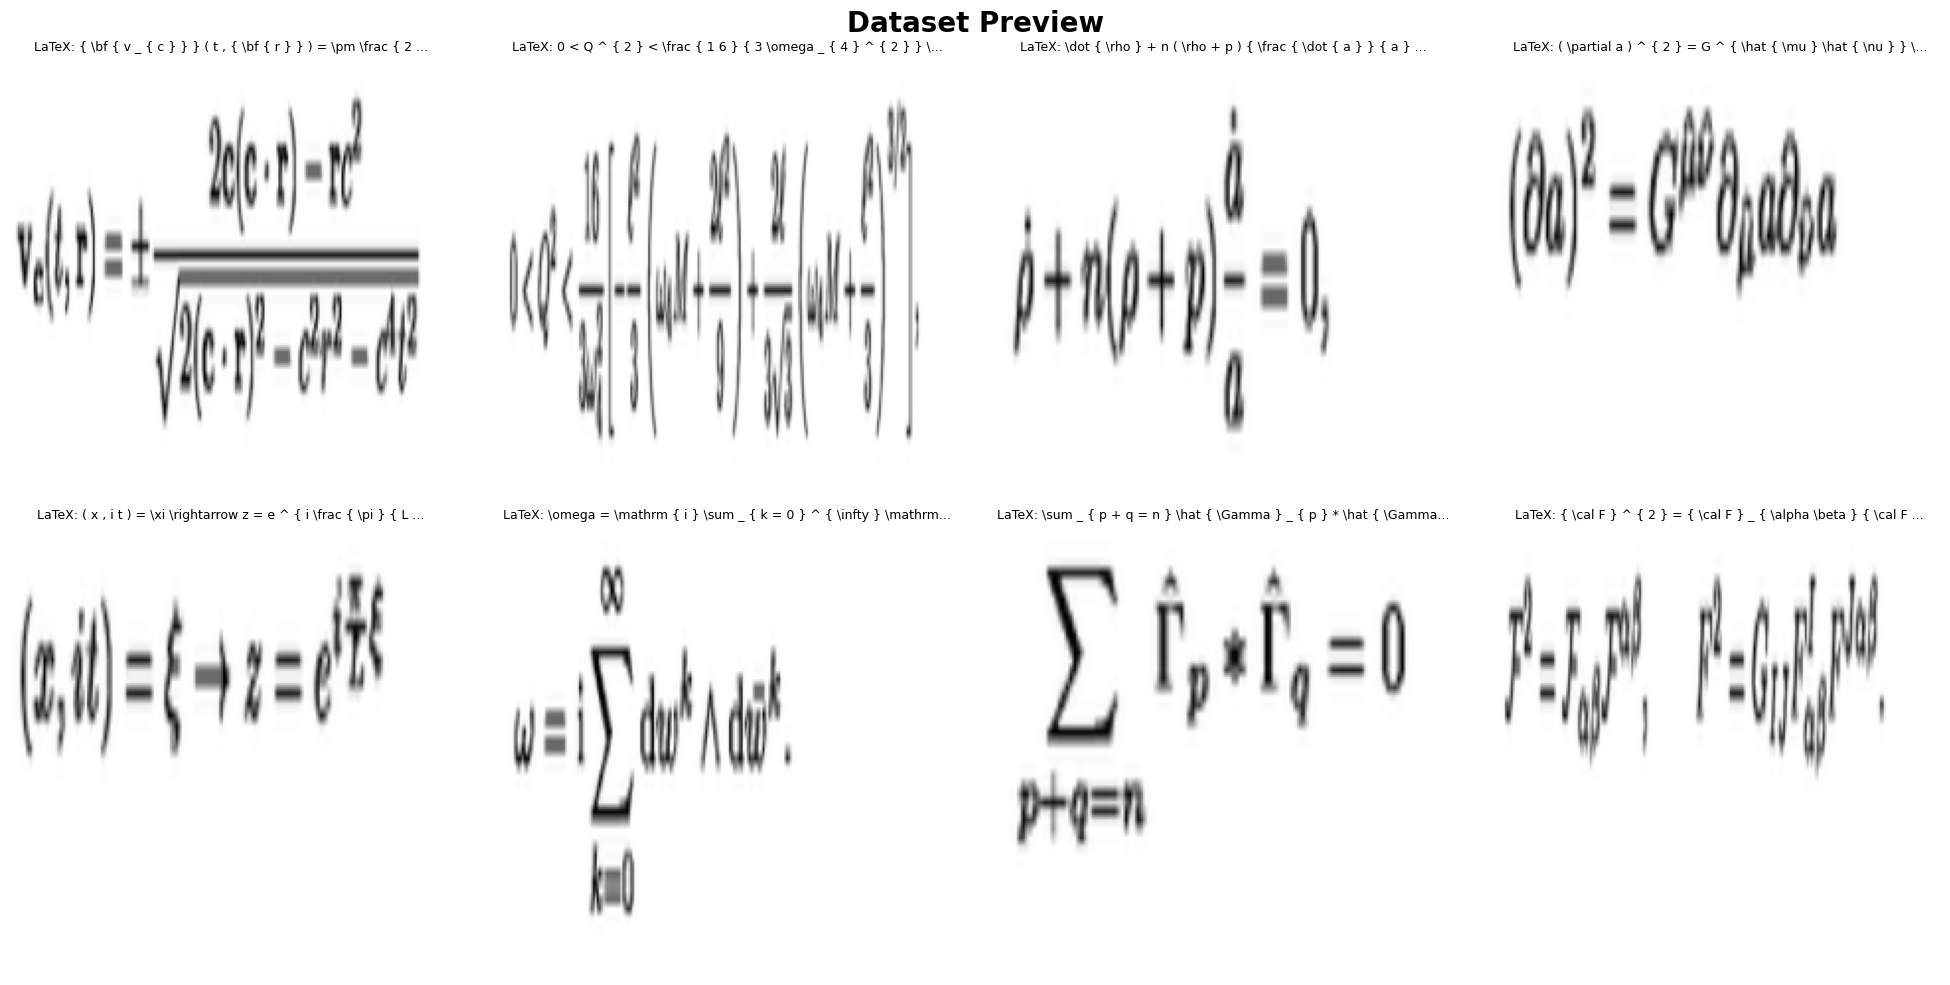


Dataset Statistics:
LaTeX Length Stats (from 1000 samples):
   • Min:     4 characters
   • Max:     509 characters
   • Average: 149.6 characters
   • Median:  132.0 characters

Sample LaTeX Formulas:
   1. \omega _ { x } ^ { ( 1 ) } = - 9 6 \cdot 1 6 \pi ^ { 2 } { \frac { x ^ { 2 } m ^...
   2. G _ { \mu \nu \lambda \tau } ^ { a b c d } ( x , y , z , u ) = < 0 ^ { + } | T [...
   3. \{ f ( x , p ) , g ( x , p ) \} _ { \theta } = \frac { f \star g - g \star f } {...
Preview complete!


In [ ]:
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

def preview_dataset(dataset, num_samples=8):
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    indices = [int(i) for i in indices]

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    fig.suptitle('Dataset Preview', fontsize=20, fontweight='bold')
    axes = axes.flatten()

    for idx, ax in enumerate(axes):
        image, latex = dataset[indices[idx]]

        img = denormalize(image)
        img = torch.clamp(img, 0, 1)
        img = img.permute(1, 2, 0).numpy()

        ax.imshow(img)
        ax.axis('off')

        latex_short = latex[:60] + '...' if len(latex) > 60 else latex
        ax.set_title(f"LaTeX: {latex_short}",
                    fontsize=9,
                    pad=10,
                    wrap=True)

    plt.tight_layout()
    plt.show()

    print("\n" + "="*70)
    print("Dataset Statistics:")
    print("="*70)

    latex_lengths = []
    sample_size = min(1000, len(dataset))
    for i in range(sample_size):
        _, latex = dataset[i]
        latex_lengths.append(len(latex))

    print(f"LaTeX Length Stats (from {len(latex_lengths)} samples):")
    print(f"   • Min:     {min(latex_lengths)} characters")
    print(f"   • Max:     {max(latex_lengths)} characters")
    print(f"   • Average: {np.mean(latex_lengths):.1f} characters")
    print(f"   • Median:  {np.median(latex_lengths):.1f} characters")

    print(f"\nSample LaTeX Formulas:")
    for i in range(3):
        rand_idx = int(np.random.randint(len(dataset)))
        _, latex = dataset[rand_idx]
        print(f"   {i+1}. {latex[:80]}{'...' if len(latex) > 80 else ''}")

    print("="*70)
full_dataset = LaTeXOCRDataset(
    hf_dataset=dataset,
    transform=transform
)

preview_dataset(full_dataset, num_samples=8)
print("Preview complete!")

## Data Splitting

In [ ]:
total_size = len(full_dataset)
train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Dataset split:")
print(f"   Train: {len(train_dataset)} samples")
print(f"   Validation: {len(val_dataset)} samples")
print(f"   Test:  {len(test_dataset)} samples")

Dataset split:
   Train: 53422 samples
   Validation: 11447 samples
   Test:  11449 samples


## Data Loader

In [ ]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print(f"DataLoaders created")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches:   {len(val_loader)}")
print(f"   Test batches:  {len(test_loader)}")

DataLoaders created
   Train batches: 3339
   Val batches:   716
   Test batches:  716


In [ ]:
print("Testing DataLoader")

images, labels = next(iter(train_loader))

print(f"Test successful")
print(f"   Batch image shape: {images.shape}")
print(f"   Batch size: {len(labels)}")
print(f"\n   First 2 formulas:")
for i in range(min(2, len(labels))):
    print(f"   {i+1}. {labels[i][:50]}...")

Testing DataLoader
Test successful
   Batch image shape: torch.Size([16, 3, 224, 224])
   Batch size: 16

   First 2 formulas:
   1. ( 1 + \omega ) / 2 , ( 1 - \omega ) / 2 , 2 ; - x ...
   2. S ( n , E , \alpha , \beta ) = \mathrm { l n } Z (...


## Data REPOERT

In [ ]:
print("="*60)
print("DATA PREPARATION COMPLETE")
print("="*60)
print(f"Dataset: LaTeXOCRDataset")
print(f"Total Samples: {len(full_dataset):,}")
print(f"\n Split:")
print(f"    Train: {len(train_dataset):,} ({len(train_dataset)/len(full_dataset)*100:.1f}%)")
print(f"    Val:   {len(val_dataset):,} ({len(val_dataset)/len(full_dataset)*100:.1f}%)")
print(f"    Test:  {len(test_dataset):,} ({len(test_dataset)/len(full_dataset)*100:.1f}%)")
print(f"\n Batch Size: {BATCH_SIZE}")
print("="*60)

DATA PREPARATION COMPLETE
Dataset: LaTeXOCRDataset
Total Samples: 76,318

 Split:
    Train: 53,422 (70.0%)
    Val:   11,447 (15.0%)
    Test:  11,449 (15.0%)

 Batch Size: 16


# Pex2Tex

In [ ]:
from pix2tex.cli import LatexOCR
import torch.nn as nn

print("Loading pix2tex model")

model = LatexOCR()

print("Model loaded")
print(f" Model type: {type(model)}")
print(f"   Device: {next(model.model.parameters()).device}")

print("="*70)
print("Model Architecture:")
print("="*70)

total_params = sum(p.numel() for p in model.model.parameters())
trainable_params = sum(p.numel() for p in model.model.parameters() if p.requires_grad)

print(f"\n Model Statistics:")
print(f"   Total Parameters: {total_params:,}")
print(f"   Trainable Parameters: {trainable_params:,}")
print(f"   Non-trainable: {total_params - trainable_params:,}")

print(f"\n Model Structure:")
print(model.model)

print("\n Model complete!")
print("="*70)


/usr/local/lib/python3.12/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.24). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_serializers.py:44: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `dict[str, any]` - serialized value may not be as expected [field_name='noise_params', input_value=UniformParams(noise_type=... 0.058823529411764705)]), input_type=UniformParams])
  v = handler(item, index)
/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `dict[str, any]` - serialized value may not be as expected [field_name='noise_params', input_value=UniformParams(noise_type=... 0.058823529411764705)])

Loading pix2tex model
download weights v0.0.1 to path /content/LaTeX-OCR/pix2tex/model/checkpoints


weights.pth: 100%|██████████| 97.4M/97.4M [00:00<00:00, 150Mb/s]
image_resizer.pth: 100%|██████████| 18.5M/18.5M [00:00<00:00, 128Mb/s] 


Model loaded
 Model type: <class 'pix2tex.cli.LatexOCR'>
   Device: cpu
Model Architecture:

 Model Statistics:
   Total Parameters: 25,498,880
   Trainable Parameters: 25,498,880
   Non-trainable: 0

 Model Structure:
Model(
  (encoder): CustomVisionTransformer(
    (patch_embed): HybridEmbed(
      (backbone): ResNetV2(
        (stem): Sequential(
          (conv): StdConv2dSame(1, 64, kernel_size=(7, 7), stride=(2, 2), bias=False)
          (norm): GroupNormAct(
            32, 64, eps=1e-05, affine=True
            (act): ReLU(inplace=True)
          )
          (pool): MaxPool2dSame(kernel_size=(3, 3), stride=(2, 2), padding=(0, 0), dilation=(1, 1), ceil_mode=False)
        )
        (stages): Sequential(
          (0): ResNetStage(
            (blocks): Sequential(
              (0): Bottleneck(
                (downsample): DownsampleConv(
                  (conv): StdConv2dSame(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
                  (norm): GroupNormAct(
     

## Freezing Encoder

In [ ]:
print("="*10)
print("Freezing Encoder")
print("="*10)

if hasattr(model.model, 'encoder'):
    for param in model.model.encoder.parameters():
        param.requires_grad = False
    print("Encoder frozen")
else:
    print("'encoder' attribute not found")
    all_params = list(model.model.parameters())
    freeze_count = len(all_params) // 2
    for param in all_params[:freeze_count]:
        param.requires_grad = False
    print(f"Froze first {freeze_count} layers")

trainable_after = sum(p.numel() for p in model.model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_after

print(f"\n After Freezing:")
print(f"  Frozen Parameters: {frozen_params:,}")
print(f"  Trainable Parameters: {trainable_after:,}")
print(f"  Reduction: {(frozen_params/total_params)*100:.1f}%")
print("="*70)

Freezing Encoder
Encoder frozen

 After Freezing:
  Frozen Parameters: 12,855,232
  Trainable Parameters: 12,643,648
  Reduction: 50.4%


## Baseline

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class CleanLaTeXDataset(Dataset):
    def __init__(self, hf_dataset):
        self.data = hf_dataset

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        img = item['image']

        # Convert to PIL Image
        if not isinstance(img, Image.Image):
            if hasattr(img, 'path'):
                img = Image.open(img['path']).convert('RGB')
            elif hasattr(img, 'bytes'):
                from io import BytesIO
                img = Image.open(BytesIO(img['bytes'])).convert('RGB')
            else:
                img = Image.fromarray(np.array(img)).convert('RGB')
        else:
            img = img.convert('RGB')

        text = item['text']
        return img, text

def pil_collate(batch):
    images = [item[0] for item in batch]
    texts = [item[1] for item in batch]
    return images, texts


Using device: cuda


In [ ]:
def strong_normalize(s):
    if not s:
        return ""
    s = re.sub(r'^\$+|\\\[|\\\]|\\\(+|\\\)+|\\begin\{.*?\}|\\end\{.*?\}', '', s)
    s = s.replace(" ", "").replace("\n", "").replace("\t", "")
    s = re.sub(r'\\frac\{([^}]*)\}\{([^}]*)\}', r'\\frac{\1}{\2}', s)
    s = re.sub(r'\{([^{}]{1})\}', r'\1', s)
    s = re.sub(r'[.,;:!?]+$', '', s)
    s = s.replace('\\cal', '\\mathcal')
    return s.strip()

def char_accuracy(pred, true):
    pred = strong_normalize(pred)
    true = strong_normalize(true)

    if len(true) == 0:
        return 0.0

    max_len = max(len(pred), len(true))
    pred = pred.ljust(max_len)
    true = true.ljust(max_len)

    matches = sum(p == t for p, t in zip(pred, true))
    return matches / max_len * 100

In [ ]:
print("Loading clean data slice for baseline test")
test_dataset_clean = load_dataset("linxy/LaTeX_OCR", split="train[20000:70000]")

baseline_test_ds = CleanLaTeXDataset(test_dataset_clean)

_, _, baseline_test_subset = random_split(
    baseline_test_ds,
    [40000, 5000, 5000],
    generator=torch.Generator().manual_seed(42)
)

baseline_test_loader = DataLoader(
    baseline_test_subset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    collate_fn=pil_collate
)

baseline_model = LatexOCR()
baseline_model.model.to('cpu')
baseline_model.model.eval()

print("Installing NLTK for BLEU score calculation")
try:
    from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
    from nltk.tokenize import word_tokenize
    import nltk
    nltk.download('punkt', quiet=True)
    nltk.download('punkt_tab', quiet=True)
except:
    !pip install -q nltk
    from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
    from nltk.tokenize import word_tokenize
    import nltk
    nltk.download('punkt', quiet=True)
    nltk.download('punkt_tab', quiet=True)

def tokenize_latex(text):
    text = strong_normalize(text)

    tokens = []
    i = 0
    while i < len(text):
        if text[i] == '\\':
            j = i + 1
            while j < len(text) and text[j].isalpha():
                j += 1
            tokens.append(text[i:j])
            i = j
        elif text[i] in '{}[]()^_':
            tokens.append(text[i])
            i += 1
        elif text[i].isspace():
            i += 1
        else:
            tokens.append(text[i])
            i += 1

    return tokens

def calculate_bleu(reference, hypothesis):
    """Calculate BLEU score with smoothing"""
    ref_tokens = tokenize_latex(reference)
    hyp_tokens = tokenize_latex(hypothesis)

    if len(ref_tokens) == 0 or len(hyp_tokens) == 0:
        return 0.0

    smooth = SmoothingFunction()

    try:
        bleu = sentence_bleu(
            [ref_tokens],
            hyp_tokens,
            smoothing_function=smooth.method1
        )
    except:
        bleu = 0.0

    return bleu * 100

print("\n" + "="*85)
print("Testing original pix2tex model")
print("="*85)

total = 0
bleu_sum = 0.0

with torch.no_grad():
    for pil_images, texts in baseline_test_loader:
        for pil_img, true_text in zip(pil_images, texts):
            if total >= 200:
                break

            pred = baseline_model(pil_img)
            bleu = calculate_bleu(true_text, pred)
            bleu_sum += bleu

            if total < 5:
                print(f"\n{'='*85}")
                print(f"Example {total+1}")
                print(f"{'='*85}")
                print(f"Actual : {strong_normalize(true_text)[:120]}")
                print(f"Prediction   : {strong_normalize(pred)[:120]}")
                print(f"Accuracy: {bleu:.2f}%")

            total += 1

        if total >= 200:
            break

final_bleu = bleu_sum / total

print("="*85)
print(f"Samples Tested: {total}")
print(f"Accuracy: {final_bleu:.2f}%")
print("="*85)

Loading clean data slice for baseline test
Installing NLTK for BLEU score calculation

Testing original pix2tex model

Example 1
Actual : ds^2=\exp(2A)d{\widetildes}^2+dy^2
Prediction   : ds^2=\exp(2A)d\tildes^2+dy^2
Accuracy: 76.44%

Example 2
Actual : \int{\mathcalD}X^{\mu}(\sigma)\exp\left\{-\frac1{4\pi\alpha^{\prime}}\int\mathrmd^2\!\sigma\eta^{\alpha\beta}\partial_{\
Prediction   : \int{\mathcalD}X^{\mu}(\sigma)\exp\left\{-\frac1{4\pi\alpha^{\prime}}\int\mathrmd^2\sigma\eta^{\alpha\beta}\partial_{\al
Accuracy: 94.37%

Example 3
Actual : \sqrt{-G}=(\sqrt{1-\dotr^2}+\frac{\xi\ddotr}{1-\dotr^2})(r+\frac{\xi}{\sqrt{1-\dotr^2}})^2\sin\sigma
Prediction   : {\sqrt{-G}}=({\sqrt{1-{\dotr^2}}}+{\frac{\xi{\dotr}}{1-{\dotr^2}}})(r+{\frac{\xi}{{\sqrt{1-{\dotr^2}}}}})^2\sin\sigma
Accuracy: 48.35%

Example 4
Actual : S({\mathcalR})<(VH^3)(H^{-2}\lambda_s^{-2}e^{-\phi})=e^{-\bar{\phi}}H\lambda_s^{-2}
Prediction   : S({\mathcalR})<(VH^3)(H^{-2}\lambda_s^{-2}e^{-\phi})=e^{-\tilde{\phi}}H\lambda_s^{

## ***FINE TUNING***

In [ ]:

# Freeze everything
for param in model.model.parameters():
    param.requires_grad = False

# Unfreeze ONLY final layers
trainable = 0
for name, param in model.model.named_parameters():

    if any(x in name.lower() for x in ['output', 'head', 'proj', 'final']):
        param.requires_grad = True
        trainable += param.numel()
        print(f"Unfrozen: {name}")

print(f"\nTrainable: {trainable:,} (~{trainable/25498880*100:.1f}%)")



✓ Unfrozen: encoder.patch_embed.proj.weight
✓ Unfrozen: encoder.patch_embed.proj.bias
✓ Unfrozen: encoder.blocks.0.attn.proj.weight
✓ Unfrozen: encoder.blocks.0.attn.proj.bias
✓ Unfrozen: encoder.blocks.1.attn.proj.weight
✓ Unfrozen: encoder.blocks.1.attn.proj.bias
✓ Unfrozen: encoder.blocks.2.attn.proj.weight
✓ Unfrozen: encoder.blocks.2.attn.proj.bias
✓ Unfrozen: encoder.blocks.3.attn.proj.weight
✓ Unfrozen: encoder.blocks.3.attn.proj.bias
✓ Unfrozen: decoder.net.attn_layers.layers.2.1.net.0.proj.weight
✓ Unfrozen: decoder.net.attn_layers.layers.2.1.net.0.proj.bias
✓ Unfrozen: decoder.net.attn_layers.layers.5.1.net.0.proj.weight
✓ Unfrozen: decoder.net.attn_layers.layers.5.1.net.0.proj.bias
✓ Unfrozen: decoder.net.attn_layers.layers.8.1.net.0.proj.weight
✓ Unfrozen: decoder.net.attn_layers.layers.8.1.net.0.proj.bias
✓ Unfrozen: decoder.net.attn_layers.layers.11.1.net.0.proj.weight
✓ Unfrozen: decoder.net.attn_layers.layers.11.1.net.0.proj.bias

Trainable: 2,630,912 (~10.3%)


In [ ]:

def train_epoch_decoder(model, train_loader, optimizer, device, epoch, max_batches=15):

    model.model.train()

    if hasattr(model.model, 'encoder'):
        model.model.encoder.eval()

    total_loss = 0
    total_bleu = 0
    num_batches = 0

    train_iter = iter(train_loader)

    progress_bar = tqdm(range(max_batches), desc=f'Epoch {epoch} [Train]')

    for batch_idx in progress_bar:
        try:
            # Get next batch
            images, texts = next(train_iter)

            batch_bleu = 0
            batch_size = 0

            for img_tensor, true_text in zip(images, texts):
                # Convert to PIL
                img_denorm = denormalize(img_tensor)
                img_denorm = torch.clamp(img_denorm, 0, 1)
                img_np = (img_denorm.cpu().numpy().transpose(1, 2, 0) * 255).astype(np.uint8)
                pil_img = Image.fromarray(img_np)

                # Predict
                pred_text = model(pil_img)
                bleu = calculate_bleu(true_text, pred_text)

                batch_bleu += bleu
                batch_size += 1

            if batch_size > 0:
                avg_bleu = batch_bleu / batch_size
                avg_loss = 100 - avg_bleu

                total_loss += avg_loss
                total_bleu += avg_bleu
                num_batches += 1

                progress_bar.set_postfix({
                    'loss': f'{avg_loss:.2f}',
                    'bleu': f'{avg_bleu:.2f}%'
                })

        except StopIteration:
            break
        except Exception as e:
            continue

    final_loss = total_loss / max(num_batches, 1)
    final_bleu = total_bleu / max(num_batches, 1)

    return final_loss, final_bleu


def validate_epoch_decoder(model, val_loader, device, max_batches=10):
    model.model.eval()

    total_bleu = 0
    num_samples = 0

    val_iter = iter(val_loader)

    with torch.no_grad():
        progress_bar = tqdm(range(max_batches), desc='Validation')

        for batch_idx in progress_bar:
            try:
                # Get next batch
                images, texts = next(val_iter)

                for img_tensor, true_text in zip(images, texts):
                    img_denorm = denormalize(img_tensor)
                    img_denorm = torch.clamp(img_denorm, 0, 1)
                    img_np = (img_denorm.cpu().numpy().transpose(1, 2, 0) * 255).astype(np.uint8)
                    pil_img = Image.fromarray(img_np)

                    pred_text = model(pil_img)
                    bleu = calculate_bleu(true_text, pred_text)

                    total_bleu += bleu
                    num_samples += 1

                avg_bleu = total_bleu / num_samples
                progress_bar.set_postfix({'bleu': f'{avg_bleu:.2f}%'})

            except StopIteration:
                break
            except:
                continue

    avg_bleu = total_bleu / max(num_samples, 1)
    avg_loss = 100 - avg_bleu

    return avg_loss, avg_bleu



In [ ]:
# Setup
model.model.to('cpu')
device = torch.device('cpu')

trainable_params = [p for p in model.model.parameters() if p.requires_grad]
optimizer = optim.Adam(trainable_params, lr=5e-5, weight_decay=1e-5)

NUM_EPOCHS = 2
TRAIN_BATCHES_PER_EPOCH = 5
VAL_BATCHES_PER_EPOCH = 2
print("="*70)
print("FINE-TUNING")
print("="*70)
print(f"Optimizer: Adam")
print(f"Learning Rate: 5e-5")
print(f"Trainable Params: {sum(p.numel() for p in trainable_params):,}")
print(f"Epochs: {NUM_EPOCHS}")
print("="*70)

history = {
    'train_loss': [],
    'train_bleu': [],
    'val_loss': [],
    'val_bleu': [],
    'epoch_time': []
}

best_val_bleu = 0

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()

    print(f"\n{'='*70}")
    print(f"EPOCH {epoch}/{NUM_EPOCHS}")
    print(f"{'='*70}")

    print(f"Training on {TRAIN_BATCHES_PER_EPOCH} batches")
    train_loss, train_bleu = train_epoch_decoder(
        model=model,
        train_loader=train_loader,
        optimizer=optimizer,
        device=device,
        epoch=epoch,
        max_batches=TRAIN_BATCHES_PER_EPOCH
    )

    print(f"\nValidating on {VAL_BATCHES_PER_EPOCH} batches")
    val_loss, val_bleu = validate_epoch_decoder(
        model=model,
        val_loader=val_loader,
        device=device,
        max_batches=VAL_BATCHES_PER_EPOCH
    )

    epoch_time = time.time() - epoch_start

    # Save history
    history['train_loss'].append(train_loss)
    history['train_bleu'].append(train_bleu)
    history['val_loss'].append(val_loss)
    history['val_bleu'].append(val_bleu)
    history['epoch_time'].append(epoch_time)

    # Print summary
    print(f"\n{'='*70}")
    print(f"EPOCH {epoch} COMPLETED:")
    print(f"{'='*70}")
    print(f"   Train Loss: {train_loss:.2f} | Train BLEU: {train_bleu:.2f}%")
    print(f"   Val Loss:   {val_loss:.2f}   | Val BLEU:   {val_bleu:.2f}%")
    print(f"   Epoch Time: {epoch_time/60:.1f} minutes")

    if val_bleu > best_val_bleu:
        best_val_bleu = val_bleu
        print(f"   🌟 NEW BEST MODEL! (BLEU: {val_bleu:.2f}%)")
    else:
        print(f"   Current Best: {best_val_bleu:.2f}%")
    print(f"{'='*70}")

# Final summary
total_time = sum(history['epoch_time'])
print("\n" + "="*70)
print("FINE-TUNING COMPLETED")
print("="*70)
print(f"BLEU: {final_bleu:.2f}%")

FINE-TUNING
Optimizer: Adam
Learning Rate: 5e-5
Trainable Params: 2,630,912
Epochs: 2

EPOCH 1/2
Training on 5 batches


Epoch 1 [Train]: 100%|██████████| 5/5 [32:32<00:00, 390.53s/it, loss=99.37, bleu=0.63%]


Validating on 2 batches



Validation: 100%|██████████| 2/2 [12:44<00:00, 382.45s/it, bleu=0.67%]


EPOCH 1 COMPLETED:
   Train Loss: 98.70 | Train BLEU: 1.30%
   Val Loss:   99.33   | Val BLEU:   0.67%
   Epoch Time: 45.3 minutes
   🌟 NEW BEST MODEL! (BLEU: 0.67%)

EPOCH 2/2
Training on 5 batches



Epoch 2 [Train]: 100%|██████████| 5/5 [22:23<00:00, 268.68s/it, loss=97.40, bleu=2.60%]


Validating on 2 batches



Validation: 100%|██████████| 2/2 [12:52<00:00, 386.47s/it, bleu=0.74%]


EPOCH 2 COMPLETED:
   Train Loss: 98.02 | Train BLEU: 1.98%
   Val Loss:   99.26   | Val BLEU:   0.74%
   Epoch Time: 35.3 minutes
   🌟 NEW BEST MODEL! (BLEU: 0.74%)

FINE-TUNING COMPLETED
BLEU: 82.77%


In [ ]:
"""## Hyperparameter Tuning: Setup"""

print("="*70)
print("HYPERPARAMETER TUNING")
print("="*70)
print("Strategy: Keep all hyperparameters fixed, only change:")
print("   • Optimizer type")
print("   • Optimizer-specific hyperparameters (lr, momentum, etc.)")
print("="*70)

# Store baseline (Adam) results
tuning_results = {
    'Adam': {
        'train_bleu': history['train_bleu'][-1] if len(history['train_bleu']) > 0 else 0,
        'val_bleu': history['val_bleu'][-1] if len(history['val_bleu']) > 0 else 0,
        'train_loss': history['train_loss'][-1] if len(history['train_loss']) > 0 else 0,
        'val_loss': history['val_loss'][-1] if len(history['val_loss']) > 0 else 0,
        'config': {
            'lr': 5e-5,
            'weight_decay': 1e-5
        }
    }
}

print(f"\n Baseline (Adam):")
print(f"   Learning Rate: 5e-5")
print("\n" + "="*70)

HYPERPARAMETER TUNING
Strategy: Keep all hyperparameters fixed, only change:
   • Optimizer type
   • Optimizer-specific hyperparameters (lr, momentum, etc.)

 Baseline (Adam):
   Learning Rate: 5e-5



In [ ]:

print("="*70)
print("TESTING: SGD with Momentum")
print("="*70)

model.model.to('cpu')
device = torch.device('cpu')

# SGD Optimizer
sgd_lr = 1e-3
sgd_momentum = 0.9
sgd_weight_decay = 1e-5

trainable_params = [p for p in model.model.parameters() if p.requires_grad]
optimizer_sgd = optim.SGD(
    trainable_params,
    lr=sgd_lr,
    momentum=sgd_momentum,
    weight_decay=sgd_weight_decay
)

print(f"Configuration:")
print(f"   Optimizer: SGD")
print(f"   Learning Rate: {sgd_lr}")
print(f"   Momentum: {sgd_momentum}")
print(f"   Weight Decay: {sgd_weight_decay}")
print(f"   Epochs: 2")
print(f"   Train Batches: 5")
print(f"   Val Batches: 3")
print("="*70)

# Training history for SGD
sgd_history = {
    'train_loss': [],
    'train_bleu': [],
    'val_loss': [],
    'val_bleu': [],
}

# Train with SGD
for epoch in range(1, 3):  # 2 epochs
    print(f"\n{'='*70}")
    print(f"SGD - Epoch {epoch}/2")
    print(f"{'='*70}")

    # Train
    train_loss, train_bleu = train_epoch_decoder(
        model, train_loader, optimizer_sgd, device, epoch, max_batches=8
    )

    # Validate
    val_loss, val_bleu = validate_epoch_decoder(
        model, val_loader, device, max_batches=3
    )

    sgd_history['train_loss'].append(train_loss)
    sgd_history['train_bleu'].append(train_bleu)
    sgd_history['val_loss'].append(val_loss)
    sgd_history['val_bleu'].append(val_bleu)

    print(f"\nEpoch {epoch} Results:")
    print(f"   Train: Loss={train_loss:.2f}, BLEU={train_bleu:.2f}%")
    print(f"   Val:   Loss={val_loss:.2f}, BLEU={val_bleu:.2f}%")

# Store results
tuning_results['SGD'] = {
    'train_bleu': sgd_history['train_bleu'][-1],
    'val_bleu': sgd_history['val_bleu'][-1],
    'train_loss': sgd_history['train_loss'][-1],
    'val_loss': sgd_history['val_loss'][-1],
    'config': {
        'lr': sgd_lr,
        'momentum': sgd_momentum,
        'weight_decay': sgd_weight_decay
    }
}

print("\n" + "="*70)
print(f"SGD Final Results:")
print(f"   Best Val BLEU: {max(sgd_history['val_bleu']):.2f}%")
print("="*70)

TESTING: SGD with Momentum
Configuration:
   Optimizer: SGD
   Learning Rate: 0.001
   Momentum: 0.9
   Weight Decay: 1e-05
   Epochs: 2
   Train Batches: 5
   Val Batches: 3

SGD - Epoch 1/2


Validation: 100%|██████████| 3/3 [14:22<00:00, 287.42s/it, bleu=1.41%]


Epoch 1 Results:
   Train: Loss=98.80, BLEU=1.20%
   Val:   Loss=98.59, BLEU=1.41%

SGD - Epoch 2/2



Epoch 2 [Train]:  80%|████████  | 4/5 [24:23<06:05, 365.95s/it, loss=97.49, bleu=2.51%]


KeyboardInterrupt: 